# 09 — Phase 3A Climate Outlook Validation
Block rainfall climatology + MJO phase-composite gate + W3/W4 backtest.

**Rule:** no new ML, MJO CNN-LSTM frozen, no future leakage. Fit period 2010–2019; test period 2020–2025. Run order: `build_normals.py` → `mjo_composites.py` → `backtest_w3w4.py` → this notebook.

## 1. Data sources
- `data/raw/rainfall/Sangrur_Block_Daily_Rainfall_2010_2025.csv` — 35,064 rows, 2010-01-01..2025-12-31, 6 blocks × 5844 d, 0 NaN, 0 dupes, units mm (verified Step 1).
- `data/raw/mjo/MJO_RMM_cleaned_core.csv` — 18,802 rows, 1974-06-01..2026-09-07, phases 1–8, one 291-d gap (1978), **provenance NOT verified**.
- `data/processed/climatology/block_doy_normals_train_2010_2019.csv` (train-frozen) + `block_doy_normals_full.csv` (**deployment only**).

## 2. Preprocessing
Zero NaNs in source; every 0.0 is an observed no-rain day (nothing filled). Feb-29 pooled into DOY 60. Per block × issue-DOY pooling over years × circular ±7 d window; no post-smoothing. Wet day: ≥ 1.0 mm (project convention, not IMD).

## 3. Leakage rules
Climatology built from dates strictly before the cutoff (`--end-date`). All composite/backtest conditioning tables fit on 2010–2019 only; test issues are weekly JJAS 2020–2025 (last issue 2025-12-01, need D+30 observed). The `full` artifact is labelled `deployment` and never used in backtests.

In [1]:
%matplotlib inline
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
ROOT = Path('.').resolve()
CLIM = (ROOT/'data/processed/climatology' if (ROOT/'data').exists()
        else ROOT.parent/'data/processed/climatology')  # kernel cwd: repo root or notebooks/
train = pd.read_csv(CLIM/'block_doy_normals_train_2010_2019.csv')
full = pd.read_csv(CLIM/'block_doy_normals_full.csv')
method = json.load(open(CLIM/'method_train_2010_2019.json'))
print(method['kind'], method['span_used'], '|', method['leakage_statement'][:80], '...')
print(train.shape, full.shape)

train-frozen ['2010-01-01', '2019-12-31'] | train-frozen: built from dates strictly before cutoff; valid for issue dates >=  ...
(2196, 12) (2196, 12)


## 4. Climatology — seasonal cycle per block (train-frozen)

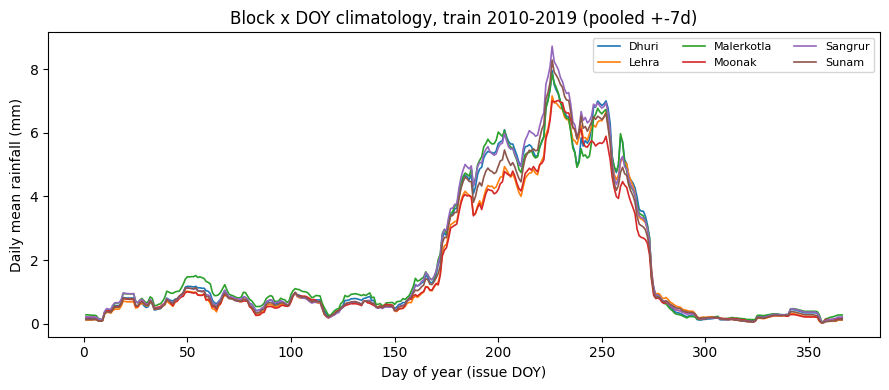

In [2]:
fig, ax = plt.subplots(figsize=(9, 4))
for b, g in train.groupby('block'):
    ax.plot(g['doy'], g['daily_mean_mm'], label=b, lw=1.2)
ax.set(xlabel='Day of year (issue DOY)', ylabel='Daily mean rainfall (mm)',
       title='Block x DOY climatology, train 2010-2019 (pooled +-7d)')
ax.legend(ncol=3, fontsize=8); fig.tight_layout(); plt.show()

## 5. MJO composites — method
Active MJO: amplitude ≥ 1.0 (Wheeler–Hendon). MJO state at issue D (operations must lag ~3 d; backtest repeats with D-3). Lead scan offsets 3/10/17/24 d (product needs 17/24 = W3/W4). Anomaly vs train climatological expected window sum. Gate (pre-registered, train JJAS/active/offset-17): GO iff ≥2 phases with |mean pct| ≥ 15%, 95% CI excludes 0, same sign in ≥5/6 blocks, same sign in 2010-2014 vs 2015-2019.

In [3]:
gate = json.load(open(CLIM/'mjo_gate.json'))
print('GATE:', gate['decision'], '| qualifying:', gate['qualifying_phases'])
comp = pd.read_csv(CLIM/'mjo_composites.csv')
j = comp[(comp.jjas==1) & (comp.active) & (comp.offset==17)]
print(j.groupby('phase').agg(n=('n','sum'), mean_pct=('mean_pct','mean')).round(1).to_string())

GATE: GO | qualifying: [2, 6, 7]
         n  mean_pct
phase               
1      846       4.6
2      654      19.2
3      372      -6.2
4      456     -12.2
5      594      -6.2
6      480     -20.8
7      198     -58.1
8      258      -7.1


## 6. MJO composites — lead decay of gate phases (train JJAS, active)

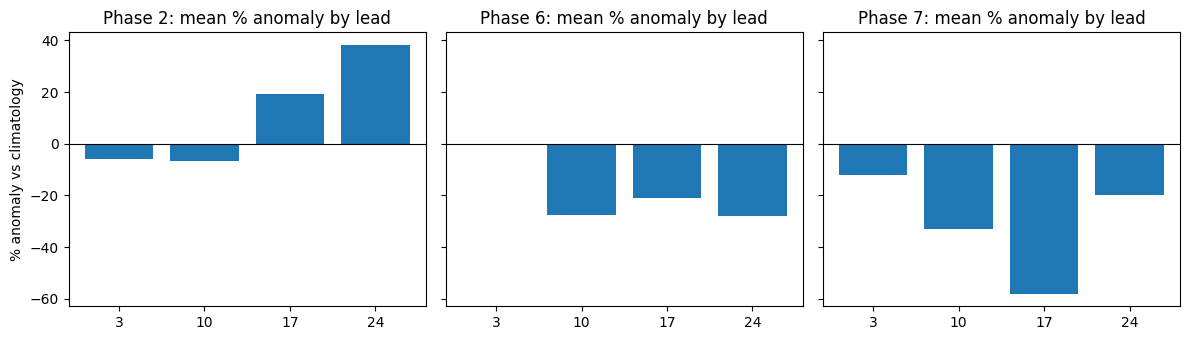

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, p in zip(axes, [2, 6, 7]):
    g = comp[(comp.phase==p) & (comp.active) & (comp.jjas==1)]
    m = g.groupby('offset')['mean_pct'].mean()
    ax.bar(m.index.astype(str), m.values)
    ax.set_title(f'Phase {p}: mean % anomaly by lead'); ax.axhline(0, color='k', lw=0.8)
axes[0].set_ylabel('% anomaly vs climatology'); fig.tight_layout(); plt.show()

## 7. Recent-rainfall baseline
Trailing-14d sums (D-14..D-1, strictly before D) terciled per (block, DOY) from train; P(W-tercile | trail-tercile) contingency from train (Laplace-smoothed). No ML.

## 8. W3/W4 targets
W3 = sum(D+17..D+23), W4 = sum(D+24..D+30) per block; labels below/near/above vs train W3/W4 terciles for the issue DOY (NOT the frozen 7-day 10.94/34.66 mm thresholds). Boundary rule: below if x ≤ t33, above if x > t66, else near.

## 9. Backtest — Brier / RPS / accuracy (test JJAS weekly 2020–2025, n=630/arm/window)

In [5]:
met = json.load(open(CLIM/'backtest_metrics.json'))
for k, v in met['arms'].items():
    if 'JJAS' in k and 'mjolag0' in k:
        print(k, v)

JJAS/W3/mjolag0/CLIM {'n': 630, 'brier': 0.6667, 'rps': 0.4683, 'accuracy': 0.3317}
JJAS/W3/mjolag0/CLIM+RECENT {'n': 630, 'brier': 0.674, 'rps': 0.475, 'accuracy': 0.2714, 'brier_skill_vs_clim': -0.0109}
JJAS/W3/mjolag0/CLIM+RECENT+MJO {'n': 630, 'brier': 0.6896, 'rps': 0.4888, 'accuracy': 0.2619, 'brier_skill_vs_clim': -0.0343}
JJAS/W4/mjolag0/CLIM {'n': 630, 'brier': 0.6667, 'rps': 0.4656, 'accuracy': 0.3333}
JJAS/W4/mjolag0/CLIM+RECENT {'n': 630, 'brier': 0.677, 'rps': 0.4754, 'accuracy': 0.3, 'brier_skill_vs_clim': -0.0154}
JJAS/W4/mjolag0/CLIM+RECENT+MJO {'n': 630, 'brier': 0.6835, 'rps': 0.4782, 'accuracy': 0.2968, 'brier_skill_vs_clim': -0.0252}


## 10. Reliability of P(above-normal) + confusion (JJAS W3)

In [6]:
for k, v in met['reliability_P_above'].items():
    if k.startswith('W3'):
        print(k, v)
print()
for k, v in met['confusion'].items():
    if k.startswith('W3'):
        print(k, v)

W3/CLIM [{'bin': '0.2-0.4', 'n': 630, 'mean_p': 0.333, 'obs_freq': 0.406}]
W3/CLIM+RECENT [{'bin': '0.2-0.4', 'n': 630, 'mean_p': 0.331, 'obs_freq': 0.406}]
W3/CLIM+RECENT+MJO [{'bin': '0.2-0.4', 'n': 571, 'mean_p': 0.312, 'obs_freq': 0.419}, {'bin': '0.4-0.6', 'n': 55, 'mean_p': 0.432, 'obs_freq': 0.291}]

W3/CLIM [[209, 0, 0], [165, 0, 0], [256, 0, 0]]
W3/CLIM+RECENT [[95, 58, 56], [100, 35, 30], [144, 71, 41]]
W3/CLIM+RECENT+MJO [[84, 74, 51], [93, 42, 30], [143, 74, 39]]


## 11. MJO go/no-go (final)
In-sample gate: GO (phases 2, 6, 7 — physically coherent with the canonical MJO–monsoon teleconnection, 6/6 block agreement). **Out-of-sample backtest: both CLIM+RECENT and CLIM+RECENT+MJO score negative Brier skill vs flat climatology (W3 −1.1%/−3.4%, W4 −1.5%/−2.5%; JJAS-only-fit sensitivity also negative).** Accuracy rises slightly but probabilities are miscalibrated (overconfident). **Final decision: NO-GO for MJO mathematics — MJO remains explanatory-only.** Recent-anomaly conditioning also fails → trailing rainfall stays display-only.

## 12. Conclusions for Phase 3B
Ship: frozen deployment climatology (normals + W3/W4 terciles + wet-day probs) and observed trailing totals/anomalies as DISPLAY. Do not ship: MJO/recent probability modifiers, any new ML, OutlookService (needs its own build step). Revisit MJO math only with calibrated probabilities on more data — not by tuning this result.